In [1]:
using Revise
using SSMCMain.ModifiedMiCRM
using SSMCMain.ModifiedMiCRM.MinimalModelV3

In [2]:
using Printf

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# beta hat

In [8]:
βhat(V, γ, l) = V * (V + γ - 1) / (γ * (V - l))

fig = Figure()
ax = Axis(fig[1, 1]; xlabel="V", ylabel="β̂")
sg = SliderGrid(fig[2, 1],
    (label="γ", range=0.1:0.01:5, startvalue=1.0),
    (label="l", range=0.01:0.01:0.99, startvalue=0.6),
    (label="p", range=0.1:0.01:5, startvalue=1.0),
)

vlines!(ax, [1.]; color=:black)

Vs = range(1, 20, 400)
lines!(ax, Vs, lift((γ, l) -> βhat.(Vs, γ, l), sg.sliders[1].value, sg.sliders[2].value))

Vs2 = range(-10, 1, 400)
lines!(ax, Vs2, lift((γ, l) -> βhat.(Vs2, γ, l), sg.sliders[1].value, sg.sliders[2].value); linestyle=:dash, color=Cycled(1))

V_c = lift([s.value for s in sg.sliders]...) do g, l, p
    (l * g) / (p * (1 - l))
end
vlines!(ax, V_c; color=:black, linestyle=:dash)

pmax_str = lift([s.value for s in sg.sliders]...) do g, l, p
    if (l + g - 1) < 0
        "No upper bound on p"
    else
        pmax = (l * g) / ((1 - l) * (l + sqrt(l * (l + g - 1))))
        @sprintf "pmax = %.5g" pmax
    end
end
Label(fig[0,:], pmax_str; tellwidth=false)

xlims!(ax, 0, 20)
ylims!(ax, 0, 20)
display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

# l star

In [65]:
fig = Figure()
ax = Axis(fig[1, 1];
    xscale=log10,
    xlabel="p",
    ylabel="̂l star"
)
lticks = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 0.999]
ax.yticks = LeakageScale.lxticks(lticks; fmt="%.3f")
ylims!(ax, LeakageScale.ltox(first(lticks)), LeakageScale.ltox(last(lticks)))
sg = SliderGrid(fig[2, 1],
    (label="log10(γ)", range=-5:0.01:5, startvalue=0.0),
)

ps = 10 .^ range(-3, 3, 10000)

function lstar(g, p)
    if p < 1
        p / (p + g)
    else
        S2 = g^2 + 4 * p * g * (p - 1)
        @assert S2 > 0
        S = sqrt(S2)
        (2 * p - g + S) / (2 * p + g + S)
    end
end

lstars = lift([s.value for s in sg.sliders]...) do logg
    g = 10 ^ logg
    map(ps) do p
        if p < 1
            p / (p + g)
        else
            S2 = g^2 + 4 * p * g * (p - 1)
            @assert S2 > 0
            S = sqrt(S2)
            (2 * p - g + S) / (2 * p + g + S)
        end
    end
end
lstar_xs = lift(lstars) do lss LeakageScale.ltox.(lss) end
lines!(ax, ps, lstar_xs)

display(GLMakie.Screen(), fig)
# fig

GLMakie.Screen(...)

# beta vs l phase diagram

In [20]:
fig = Figure()
ax = Axis(fig[1, 1];
    xscale=log10,
    xlabel="β̂",
    ylabel="l"
)
lticks = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 0.999]
ax.yticks = LeakageScale.lxticks(lticks; fmt="%.3f")
ylims!(ax, LeakageScale.ltox(first(lticks)), LeakageScale.ltox(last(lticks)))
sg = SliderGrid(fig[2, 1],
    (label="log10(γ)", range=-5:0.01:5, startvalue=0.0),
    (label="log10(p)", range=-5:0.01:5, startvalue=0.0),
)

ls = LeakageScale.lxrange(1e-3, 1000)
leak_xs = LeakageScale.ltox.(ls)

lstar = lift([s.value for s in sg.sliders]...) do logg, logp fr3_lstar(10 ^ logp, 10 ^ logg)  end
hlines!(ax, lift(LeakageScale.ltox, lstar);
    color=:gray
)

bvs = lift(sg.sliders[1].value) do logg fr3_beta_viable.(ls, 10 ^ logg) end
lines!(ax, bvs, leak_xs;
    color=:black,
)

bcs = lift([s.value for s in sg.sliders]...) do logg, logp fr3_beta_c_qualified.(ls, 10 ^ logg, 10 ^ logp) end
lines!(ax, bcs, leak_xs;
    color=:black,
    linestyle=:dash,
)

bcs2 = lift([s.value for s in sg.sliders]...) do logg, logp fr3_beta_c_approx1.(ls, 10 ^ logp) end
lines!(ax, bcs2, leak_xs;
    color=Cycled(1),
    linestyle=:dash,
)
lx = lift([s.value for s in sg.sliders]...) do logg, logp 1 - (10 ^ logg) / (10 ^ logp)  end
hlines!(ax, lift(LeakageScale.ltox, lx);
    color=Cycled(1)
)

xlims!(ax, 0.5, 1e4)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

In [27]:
extrema(bcs[])

(-9.41504494810004, 64.97772498695423)

# beta_c vs leakage

In [37]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel="l", ylabel="β_c")
sg = SliderGrid(fig[2, 1],
    (label="log10(γ)", range=-5:0.01:5, startvalue=0.0),
    (label="log10(p)", range=-5:0.01:5, startvalue=0.0),
)

ls = range(0.001, 0.999, 400)

bcs = lift([s.value for s in sg.sliders]...) do logg, logp
    g = 10 ^ logg
    p = 10 ^ logp
    fr3_beta_c.(ls, g, p)
end
lines!(ax, ls, bcs; color=:black, label="beta_c")

lstar = lift([s.value for s in sg.sliders]...) do logg, logp
    g = 10 ^ logg
    p = 10 ^ logp
    fr3_lstar(p, g)
end
vlines!(ax, lstar; color=:orange, label="l star")

bviable = lift([s.value for s in sg.sliders]...) do logg, logp
    g = 10 ^ logg
    fr3_beta_viable.(ls, g)
end
lines!(ax, ls, bviable; color=(:black, 0.3), linestyle=:dash, label="beta_viable")

axislegend(ax)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

In [77]:
fr3_beta_c_qualified(0.99, 1e-2, 0.1)

989.9999999999992

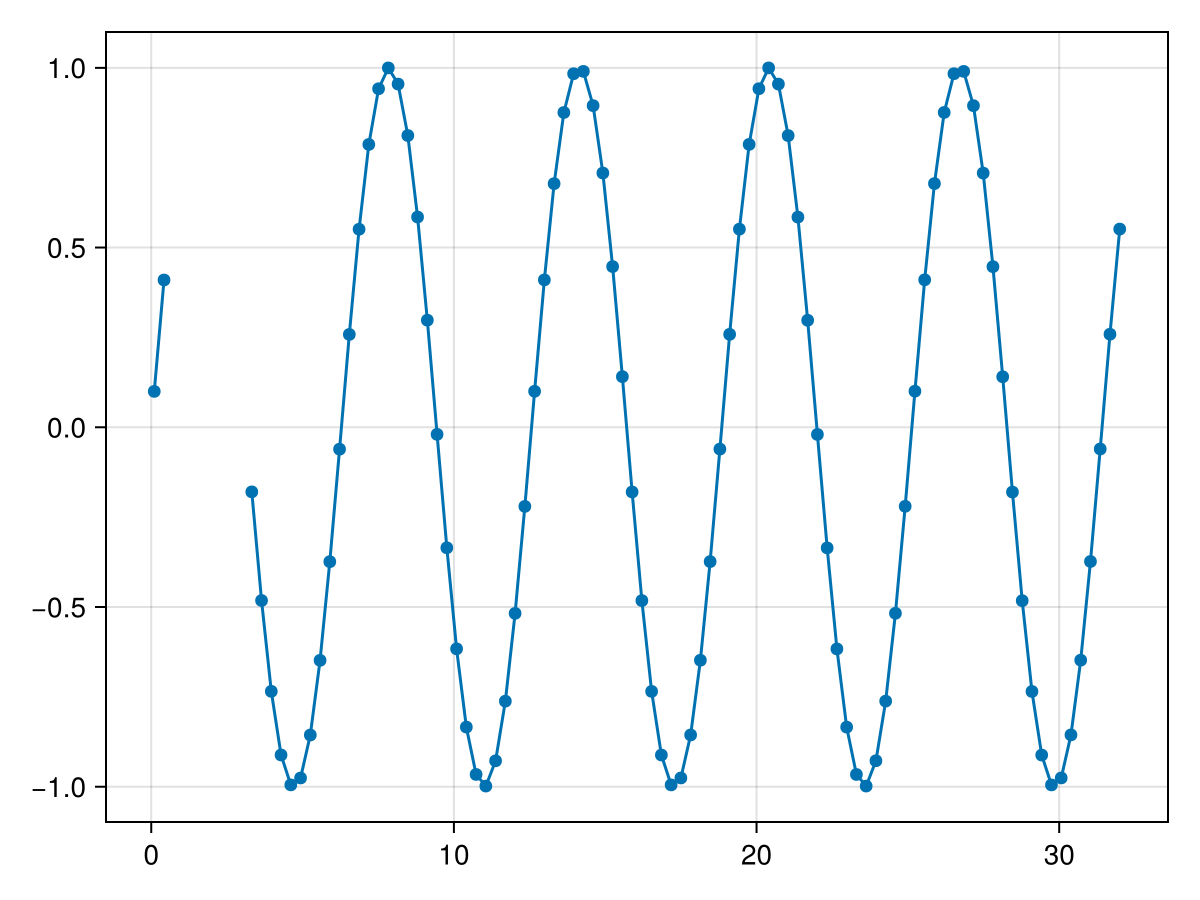

In [48]:
xs = range(0.1, 32., 100)
ys = Vector{Any}(undef, 100)
ys .= sin.(xs)
ys[3:10] .= missing
scatterlines(xs, ys)